<a href="https://colab.research.google.com/github/hawa1983/MG-628/blob/main/CLT_Sampling_Simulation_PublicAdmin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulation Notebook: The Central Limit Theorem, Standard Error, Confidence Intervals, and P-values
### Public Administration (MPA) — Fast-Track Vocational Training

**Course:** MG628 — Data Analysis for Managerial Decision-Making
**Dataset:** `employment_program.csv`
**Variable we'll simulate with:** `Monthly_Income` (monthly income in US dollars)

---
**How this notebook works:**
- Every **code cell** is preceded by a **text cell** explaining *what* the code does, *why* we're doing it, and *how* to interpret the output.
- Inside each code cell, every line (or small group of lines) has a `#` comment.
- This notebook is written for students who are **new to Python** — read the comments before moving on if anything looks unfamiliar.

---
### What This Notebook Demonstrates
This notebook does NOT ask you to write a recommendation memo. Instead, it's a **hands-on lab** that lets you SEE four core statistical ideas happen, using your own participants data:

1. **The Central Limit Theorem (CLT):** Even if our raw data isn't perfectly bell-shaped, the distribution of SAMPLE MEANS becomes approximately normal.
2. **Standard Error vs. Sample Size:** As sample size (n) grows, the standard error shrinks — our estimates get more precise.
3. **Confidence Intervals vs. Sample Size:** As n grows, confidence intervals get NARROWER — we become more certain about the true population value.
4. **P-values and Hypothesis Testing vs. Sample Size:** As n grows, it becomes easier to detect a REAL effect as "statistically significant" — small samples can miss real effects entirely.

### Context
We'll use the `Monthly_Income` column from the Fast-Track Vocational Training dataset — the same variable from our Week 8 regression analysis — as our "population" of 300 participants. In this notebook, we'll repeatedly draw random samples of participants and study how the sample mean of Monthly_Income behaves.


## Step 0 — Setup: Importing Our Tools
> **Purpose of this cell:** Load every Python library we will need for this notebook.
> **Methodology:** Same five core libraries as our Week 8 analysis notebook, plus we'll use `numpy`'s random number generator extensively to draw repeated random samples ("resampling").

### A Note on Randomness
This notebook relies on RANDOM sampling — every time we "draw a sample," Python picks rows at random. To make sure everyone in class gets the SAME random results (so we can discuss them together), we set a **random seed** with `np.random.seed(42)`. The number 42 has no special meaning — it's just a fixed starting point for the random number generator, so "random" results are reproducible.


In [ ]:
# Import pandas: for loading and manipulating our dataset (tables of data)
import pandas as pd

# Import numpy: for numerical operations AND for drawing random samples
import numpy as np

# Import matplotlib's plotting module: for drawing charts
import matplotlib.pyplot as plt

# Import seaborn: makes some statistical charts (like overlaying a normal curve) easier
import seaborn as sns

# Import the "stats" toolbox from scipy: for confidence intervals, t-tests, and the normal distribution
from scipy import stats

# Display charts directly inside the notebook
%matplotlib inline

# Set a "random seed" so that every time we run this notebook, we get the SAME random samples
# This makes our results reproducible -- everyone running this notebook sees the same numbers
np.random.seed(42)

print("Libraries imported and random seed set. Ready to begin!")


Libraries imported and random seed set. Ready to begin!


## Step 0.5 — Load the Data
> **Purpose of this cell:** Load `employment_program.csv` and pull out the single column we'll use throughout this notebook: `Monthly_Income`.
> **Methodology:** For this simulation, we treat ALL 300 participants as our "population" — the entire group we're interested in. In real life, your actual population would be much larger (every participant who could ever use the program), but for this exercise, our 300 rows represent that population.


In [ ]:
# Load the CSV file into a DataFrame
df = pd.read_csv('employment_program.csv')

# Pull out the Monthly_Income column as our "population" data -- a simple array of 300 numbers
population = df['Monthly_Income'].values

# Calculate the TRUE population mean (the average of all 300 values)
population_mean = np.mean(population)

# Calculate the TRUE population standard deviation (how spread out the 300 values are)
population_std = np.std(population)

# Print the size, mean, and standard deviation of our "population"
print(f"Population size (N): {len(population)}")
print(f"Population mean: {population_mean:.2f}")
print(f"Population standard deviation: {population_std:.2f}")


Population size (N): 300
Population mean: 3210.38
Population standard deviation: 584.69


## Part 0.5 — Descriptive Statistics and KPIs
> **Purpose of this cell:** Before doing ANY inferential statistics (CLT, confidence intervals, p-values, etc.), build a clean, professional **descriptive statistics summary** — the kind of table and KPIs you'd put on the FIRST slide of a presentation to orient your audience.
> **Methodology:** Use `.groupby('Group').agg(...)` (the same pattern from Week 8 Task 2) to calculate a full set of descriptive statistics — count, mean, median, standard deviation, minimum, and maximum — for BOTH `Confidence_Score` and `Monthly_Income`, separately for Control and Treatment.

### What is a KPI?
A **Key Performance Indicator (KPI)** is a single number that summarizes something important about performance — the kind of number that goes on a dashboard. In this notebook, our KPIs are:
- **Average Confidence Score** per group
- **Average Monthly Income (USD)** per group
- **Median Monthly Income (USD)** per group (the median is less affected by extreme outliers than the mean)
- **Spread (standard deviation)** of Monthly Income (USD) per group (how consistent vs. variable each group is)

### New Concepts in This Cell
- **`.agg(['count', 'mean', 'median', 'std', 'min', 'max'])`** — same `.agg()` pattern as Week 8, but now we ask for SIX statistics at once instead of two.
- **`.T` (transpose)** — flips rows and columns. We use this so our final table reads more like a typical "KPI dashboard" with metrics down the side and groups across the top.


In [ ]:
# Calculate count, mean, median, standard deviation, min, and max
# for BOTH Confidence_Score and Monthly_Income, separately for each Group
descriptive_stats = df.groupby('Group')[['Confidence_Score', 'Monthly_Income']].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
).round(2)

# Display the full descriptive statistics table
print("===== FULL DESCRIPTIVE STATISTICS TABLE =====")
print(descriptive_stats)

# Build a smaller "KPI dashboard" table with just the headline numbers, one row per KPI
kpi_dashboard = pd.DataFrame({
    'Control':   [descriptive_stats.loc['Control',   ('Confidence_Score', 'mean')],
                  descriptive_stats.loc['Control',   ('Monthly_Income', 'mean')],
                  descriptive_stats.loc['Control',   ('Monthly_Income', 'median')],
                  descriptive_stats.loc['Control',   ('Monthly_Income', 'std')]],
    'Treatment': [descriptive_stats.loc['Treatment', ('Confidence_Score', 'mean')],
                  descriptive_stats.loc['Treatment', ('Monthly_Income', 'mean')],
                  descriptive_stats.loc['Treatment', ('Monthly_Income', 'median')],
                  descriptive_stats.loc['Treatment', ('Monthly_Income', 'std')]]
}, index=['Avg Confidence Score', 'Avg Monthly Income (USD)',
           'Median Monthly Income (USD)', 'Std Dev of Monthly Income (USD)'])

print("\n===== KPI DASHBOARD =====")
print(kpi_dashboard.round(2))


===== FULL DESCRIPTIVE STATISTICS TABLE =====
          Confidence_Score                               Monthly_Income  \
                     count  mean median   std  min   max          count   
Group                                                                     
Control                150  6.00   5.90  1.85  1.4  10.0            150   
Treatment              150  7.49   7.55  1.52  3.1  10.0            150   

                                                       
              mean   median     std      min      max  
Group                                                  
Control    2851.66  2824.38  491.86  1553.13  4147.64  
Treatment  3569.09  3542.58  432.78  2537.39  4556.22  

===== KPI DASHBOARD =====
                                 Control  Treatment
Avg Confidence Score                6.00       7.49
Avg Monthly Income (USD)         2851.66    3569.09
Median Monthly Income (USD)      2824.38    3542.58
Std Dev of Monthly Income (USD)   491.86     432.78


## Part 0.5 (continued) — Visual Dashboard: Distributions and KPI Bars
> **Purpose of this cell:** Build a 2x2 grid of charts — a complete "descriptive statistics dashboard" — showing the SHAPE (histograms), CONSISTENCY (box plots), and HEADLINE KPIs (bar chart) for both groups.
> **Methodology:** We use `plt.subplots(2, 2, figsize=...)` to create a 2-row, 2-column grid of charts all at once, then draw a different chart into each of the 4 panels (`axes[0,0]`, `axes[0,1]`, `axes[1,0]`, `axes[1,1]`).

### New Concepts in This Cell
- **`fig, axes = plt.subplots(2, 2, figsize=(13, 9))`** — instead of calling `plt.subplot()` four separate times, this ONE line creates a 2x2 grid of "axes" (individual chart areas) all at once. `axes` is a 2x2 array, so `axes[0, 0]` is the top-left panel, `axes[1, 1]` is the bottom-right panel, and so on.
- **`ax.hist(...)`, `ax.boxplot(...)`, `ax.bar(...)`** — when working with `axes` instead of `plt` directly, we call these methods ON the specific panel (`ax`) we want to draw into.
- **`fig.suptitle(...)`** — adds ONE big title across the ENTIRE 2x2 grid (separate from each panel's own smaller title).

### The Four Panels
1. **Top-left:** Overlapping histogram of Confidence Score by group
2. **Top-right:** Overlapping histogram of Monthly Income (USD) by group
3. **Bottom-left:** Side-by-side box plots of Monthly Income (USD) by group
4. **Bottom-right:** KPI bar chart comparing average Confidence Score and average Monthly Income (USD) between groups


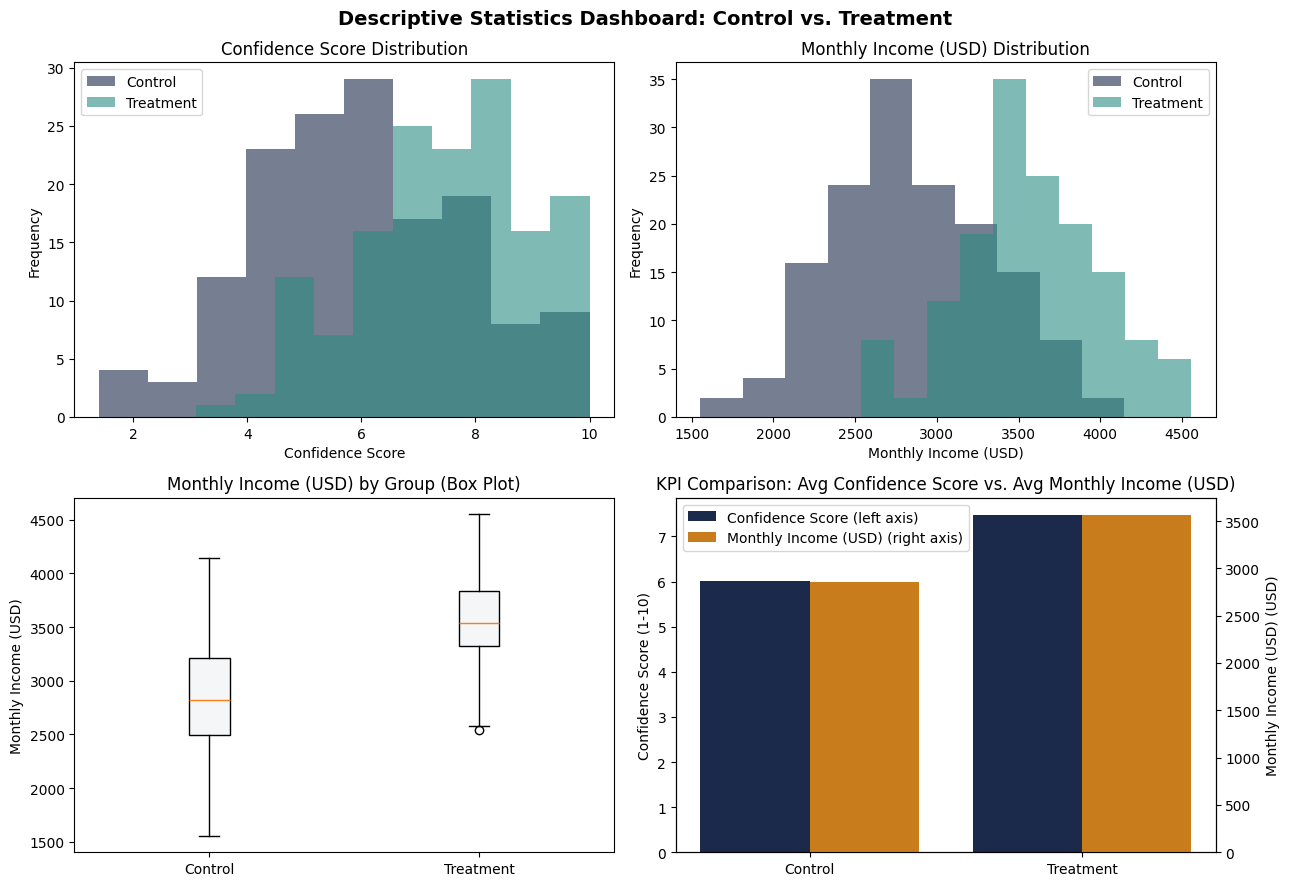

In [ ]:
# Pull out each group's data for both variables (same pattern as Week 8)
ctrl_score = df[df['Group'] == 'Control']['Confidence_Score']
trt_score  = df[df['Group'] == 'Treatment']['Confidence_Score']
ctrl_outcome = df[df['Group'] == 'Control']['Monthly_Income']
trt_outcome  = df[df['Group'] == 'Treatment']['Monthly_Income']

# Create a 2x2 grid of chart panels, 13 inches wide and 9 inches tall total
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# --- TOP-LEFT: histogram of Confidence Score by group ---
axes[0, 0].hist(ctrl_score, bins=10, alpha=0.6, label='Control', color='#1B2A4A')
axes[0, 0].hist(trt_score, bins=10, alpha=0.6, label='Treatment', color='#2A8C82')
axes[0, 0].set_xlabel('Confidence Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Confidence Score Distribution')
axes[0, 0].legend()

# --- TOP-RIGHT: histogram of Monthly Income (USD) by group ---
axes[0, 1].hist(ctrl_outcome, bins=10, alpha=0.6, label='Control', color='#1B2A4A')
axes[0, 1].hist(trt_outcome, bins=10, alpha=0.6, label='Treatment', color='#2A8C82')
axes[0, 1].set_xlabel('Monthly Income (USD)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Monthly Income (USD) Distribution')
axes[0, 1].legend()

# --- BOTTOM-LEFT: box plots of Monthly Income (USD) by group ---
axes[1, 0].boxplot([ctrl_outcome, trt_outcome], tick_labels=['Control', 'Treatment'],
                    patch_artist=True,
                    boxprops=dict(facecolor='#F4F6F8'))
axes[1, 0].set_ylabel('Monthly Income (USD)')
axes[1, 0].set_title('Monthly Income (USD) by Group (Box Plot)')

# --- BOTTOM-RIGHT: KPI bar chart (average score and average outcome, side by side) ---
# Because the two KPIs are on very different scales (a 1-10 score vs. a dollar amount),
# we use a SECOND y-axis (ax2) so both bars are readable on the same chart
ax = axes[1, 1]
ax2 = ax.twinx()  # create a second y-axis that shares the same x-axis

groups = ['Control', 'Treatment']
score_means = [ctrl_score.mean(), trt_score.mean()]
outcome_means = [ctrl_outcome.mean(), trt_outcome.mean()]

# Bars for the score KPI (left y-axis), shifted slightly left
ax.bar([0 - 0.2, 1 - 0.2], score_means, width=0.4, color='#1B2A4A', label='Confidence Score (left axis)')
# Bars for the outcome KPI (right y-axis), shifted slightly right
ax2.bar([0 + 0.2, 1 + 0.2], outcome_means, width=0.4, color='#C97C1C', label='Monthly Income (USD) (right axis)')

ax.set_xticks([0, 1])
ax.set_xticklabels(groups)
ax.set_ylabel('Confidence Score (1-10)')
ax2.set_ylabel('Monthly Income (USD) (USD)')
ax.set_title('KPI Comparison: Avg Confidence Score vs. Avg Monthly Income (USD)')

# Combine legends from both axes into one
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles1 + handles2, labels1 + labels2, loc='upper left')

# Add one big title across all four panels
fig.suptitle('Descriptive Statistics Dashboard: Control vs. Treatment', fontsize=14, fontweight='bold')

# Adjust spacing so panels don't overlap, then display
plt.tight_layout()
plt.show()


### Written Interpretation — Part 0.5 (Descriptive Statistics & KPIs)
> **Purpose of this cell:** Identify the headline numbers you'll use to OPEN your presentation.

**Instructions:** Write 3-4 sentences addressing:
- **Headline KPIs:** Looking at your KPI dashboard table, which 2-3 numbers would you put on the FIRST slide of your presentation, and why?
- **Mean vs. median:** For Monthly Income (USD), how close are the mean and median for each group? If they're very different, what would that suggest about the shape of the distribution (e.g., outliers or skew)?
- **Consistency:** Which group has a LARGER standard deviation for Monthly Income (USD) — meaning its participants are more spread out / less predictable? Why might that matter to the city council and Department of Labor?
- **First impressions vs. final conclusions:** Based ONLY on this descriptive dashboard (before any hypothesis testing), what would your INITIAL impression be about whether expanding the Fast-Track program is a good idea? Keep this in mind — you'll revisit it after Parts 1-8!

---

`# TODO (your interpretation):`


## Part 1 — What Does the Population Distribution Look Like?
> **Purpose of this cell:** Visualize the distribution of Monthly Income (USD) across ALL 300 participants (our "population"), before we do any sampling.
> **Methodology:** Draw a histogram of every value in `population`, and overlay a vertical line at the population mean.

### Why does this matter?
The CLT is impressive BECAUSE it works even when the original data ISN'T a perfect bell curve. Before we start resampling, let's look at the SHAPE of our actual data — is it symmetric? Skewed? Does it have a long tail? Keep this picture in mind — we're about to compare it to the distribution of SAMPLE MEANS.


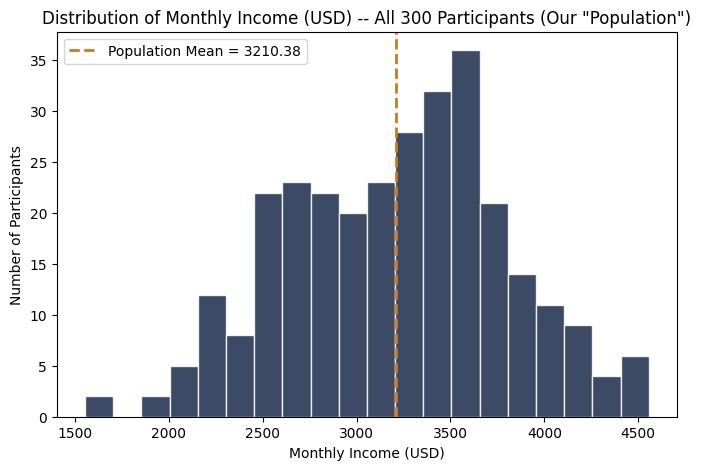

In [ ]:
# Create a figure 8 inches wide and 5 inches tall
plt.figure(figsize=(8, 5))

# Draw a histogram of all 300 population values, using 20 bins (bars)
plt.hist(population, bins=20, color='#1B2A4A', edgecolor='white', alpha=0.85)

# Draw a vertical dashed line at the population mean
plt.axvline(population_mean, color='#C97C1C', linestyle='--', linewidth=2,
            label=f'Population Mean = {population_mean:.2f}')

# Label the axes and add a title
plt.xlabel('Monthly Income (USD)')
plt.ylabel('Number of Participants')
plt.title('Distribution of Monthly Income (USD) -- All 300 Participants (Our "Population")')

# Show the legend
plt.legend()

# Display the chart
plt.show()


### Quick Reflection — Part 1
> **Purpose of this cell:** A short pause to describe what you see, before moving on.

**Instructions:** In 1-2 sentences, describe the SHAPE of this distribution. Is it symmetric (roughly mirror-image on both sides of the mean), or skewed (longer tail on one side)? Does it look like a "normal" bell curve, or not?

---

`# TODO (your observation):`


## Part 2 — The Central Limit Theorem: Resampling to Build a Sampling Distribution
> **Purpose of this cell:** Simulate drawing MANY different random samples of size **n = 30** from our population, calculate the MEAN of each sample, and store all those means. Then plot the distribution of these SAMPLE MEANS.
> **Methodology:** We repeat the following process **2,000 times**:
> 1. Randomly draw 30 participants from our population of 300 (this is called "resampling").
> 2. Calculate the average Monthly Income (USD) for THIS sample.
> 3. Record that average in a list.
>
> After 2,000 repetitions, we have 2,000 different sample means. The distribution of THOSE means is called the **sampling distribution of the mean**.

### New Concepts in This Cell
- **`np.random.choice(population, size=n, replace=True)`** — randomly picks `n` values from `population`. `replace=True` means a single participant COULD be picked more than once in the same sample (this is called sampling **"with replacement"**, and it's the standard way to simulate "what if we drew a brand-new sample from the population?").
- **A `for` loop that repeats 2,000 times** — each time through the loop, we draw a new sample, compute its mean, and `.append()` that mean to a growing list.
- **`sample_means = np.array(sample_means)`** — converts our Python list into a numpy array, which makes it easy to calculate statistics on it afterward (mean, std, etc.).


In [ ]:
# How many participants to include in EACH sample
sample_size = 30

# How many times to repeat the sampling process
n_simulations = 2000

# Create an empty list to store the mean of each sample we draw
sample_means = []

# Repeat the sampling process n_simulations times
for i in range(n_simulations):
    # Randomly draw `sample_size` values from the population, WITH replacement
    sample = np.random.choice(population, size=sample_size, replace=True)
    # Calculate the mean of THIS sample
    this_mean = np.mean(sample)
    # Add this sample's mean to our growing list
    sample_means.append(this_mean)

# Convert the list of sample means into a numpy array for easy statistics
sample_means = np.array(sample_means)

# Print a summary of what we just did
print(f"Drew {n_simulations:,} random samples, each of size {sample_size}")
print(f"Mean of the {n_simulations:,} sample means: {np.mean(sample_means):.2f}")
print(f"Standard deviation of the {n_simulations:,} sample means (this IS the standard error!): {np.std(sample_means):.2f}")
print(f"Population mean (for comparison): {population_mean:.2f}")


Drew 2,000 random samples, each of size 30
Mean of the 2,000 sample means: 3214.24
Standard deviation of the 2,000 sample means (this IS the standard error!): 107.61
Population mean (for comparison): 3210.38


## Part 2 (continued) — Side-by-Side Comparison: Population vs. Sampling Distribution
> **Purpose of this cell:** Plot TWO histograms side by side: (left) the original population data, and (right) the 2,000 sample means we just generated, with a normal curve overlaid.
> **Methodology:** We use `plt.subplot()` to place both charts in one figure, and `scipy.stats.norm.pdf()` to draw the theoretical bell-curve shape on top of our sample means histogram.

### New Concepts in This Cell
- **`stats.norm.pdf(x, mean, std)`** — calculates the height of a theoretical normal (bell curve) distribution at each x-value, given a mean and standard deviation. We use this to draw a smooth bell curve ON TOP of our histogram, so we can visually check: "do our sample means really follow this bell shape?"
- **`density=True`** in `plt.hist()` — normally a histogram's y-axis shows COUNTS (how many values fell in each bar). `density=True` rescales the y-axis so the histogram's TOTAL AREA equals 1 — this is necessary so the histogram and the normal curve are on the same scale and can be compared directly.

### What to Look For
- The LEFT chart (population) may be skewed, lumpy, or irregular.
- The RIGHT chart (sample means) should look much more like a smooth, symmetric bell curve — AND it should be MUCH NARROWER than the left chart, even though both charts use a similar x-axis range.


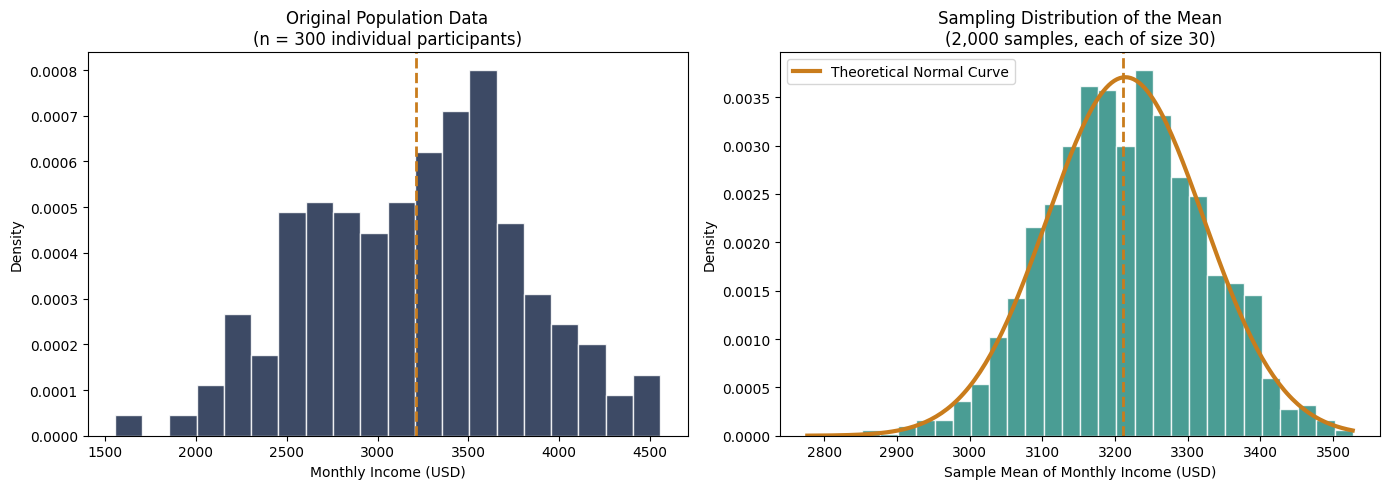

In [ ]:
# Create a figure 14 inches wide and 5 inches tall
plt.figure(figsize=(14, 5))

# --- LEFT CHART: Original population distribution ---
plt.subplot(1, 2, 1)
plt.hist(population, bins=20, color='#1B2A4A', edgecolor='white', alpha=0.85, density=True)
plt.axvline(population_mean, color='#C97C1C', linestyle='--', linewidth=2)
plt.xlabel('Monthly Income (USD)')
plt.ylabel('Density')
plt.title('Original Population Data\n(n = 300 individual participants)')

# --- RIGHT CHART: Sampling distribution of the mean ---
plt.subplot(1, 2, 2)
plt.hist(sample_means, bins=30, color='#2A8C82', edgecolor='white', alpha=0.85, density=True)

# Overlay a theoretical normal curve using the mean and std of our sample means
x_vals = np.linspace(sample_means.min(), sample_means.max(), 200)
normal_curve = stats.norm.pdf(x_vals, np.mean(sample_means), np.std(sample_means))
plt.plot(x_vals, normal_curve, color='#C97C1C', linewidth=3, label='Theoretical Normal Curve')

plt.axvline(population_mean, color='#C97C1C', linestyle='--', linewidth=2)
plt.xlabel('Sample Mean of Monthly Income (USD)')
plt.ylabel('Density')
plt.title(f'Sampling Distribution of the Mean\n({n_simulations:,} samples, each of size {sample_size})')
plt.legend()

# Adjust spacing and display
plt.tight_layout()
plt.show()


### Written Interpretation — Part 2 (The CLT)
> **Purpose of this cell:** Connect what you just saw to the Central Limit Theorem from lecture.

**Instructions:** Write 3-4 sentences addressing:
- **Shape:** How does the shape of the RIGHT chart (sample means) compare to the LEFT chart (original data)? Does the right chart look more "normal" (bell-shaped)?
- **Spread:** Which chart is WIDER (more spread out) — the population data, or the sampling distribution of the mean? Why do you think that is?
- **Center:** Where is the sampling distribution centered, compared to the population mean (the dashed line)?
- **The CLT, in your own words:** Based on this simulation, explain the Central Limit Theorem to someone who has never taken a statistics class.

---

`# TODO (your interpretation):`


## Part 3 — The Effect of Sample Size on Standard Error (SE)
> **Purpose of this cell:** Repeat the Part 2 simulation for SEVERAL different sample sizes (5, 10, 30, 50, 100, 200), and see how the spread of the sampling distribution — the standard error — changes as sample size grows.
> **Methodology:** For EACH sample size `n` in our list, we draw 1,000 samples of that size, calculate the mean of each, and then calculate the STANDARD DEVIATION of all those means. That standard deviation IS the (empirically estimated) standard error for that sample size. We compare this to the THEORETICAL formula from lecture: **SE = population standard deviation / sqrt(n)**.

### New Concepts in This Cell
- **Nested loops:** We now have a loop INSIDE a loop. The OUTER loop goes through each sample size (`5, 10, 30, ...`). The INNER loop repeats the resampling process 1,000 times FOR THAT sample size. This is the same resampling idea as Part 2, just repeated once per sample size.
- **Dictionaries (`results = {}`)** — a dictionary stores information as `key: value` pairs. Here, we'll use it to store, for each sample size, both the EMPIRICAL standard error (from our simulation) and the THEORETICAL standard error (from the formula).


In [ ]:
# The list of sample sizes we want to compare
sample_sizes = [5, 10, 30, 50, 100, 200]

# How many times to repeat the resampling process FOR EACH sample size
n_simulations_se = 1000

# Empty lists to store our results -- one entry per sample size
empirical_se_list = []   # standard error CALCULATED from our simulation
theoretical_se_list = [] # standard error CALCULATED from the formula: population_std / sqrt(n)

# OUTER LOOP: go through each sample size we want to test
for n in sample_sizes:
    # Empty list to hold the sample means for THIS sample size
    means_for_this_n = []

    # INNER LOOP: repeat the resampling process n_simulations_se times
    for i in range(n_simulations_se):
        sample = np.random.choice(population, size=n, replace=True)  # draw a random sample of size n
        means_for_this_n.append(np.mean(sample))                      # record this sample's mean

    # The EMPIRICAL standard error = the standard deviation of all these sample means
    empirical_se = np.std(means_for_this_n)
    empirical_se_list.append(empirical_se)

    # The THEORETICAL standard error = population_std / sqrt(n)
    theoretical_se = population_std / np.sqrt(n)
    theoretical_se_list.append(theoretical_se)

# Build a small table comparing the two, for every sample size
se_table = pd.DataFrame({
    'Sample Size (n)': sample_sizes,
    'Empirical SE (from simulation)': np.round(empirical_se_list, 2),
    'Theoretical SE (formula)': np.round(theoretical_se_list, 2)
})

print(se_table)


   Sample Size (n)  Empirical SE (from simulation)  Theoretical SE (formula)
0                5                          258.23                    261.48
1               10                          180.79                    184.89
2               30                          108.23                    106.75
3               50                           81.97                     82.69
4              100                           59.40                     58.47
5              200                           42.59                     41.34


## Part 3 (continued) — Plotting SE vs. Sample Size
> **Purpose of this cell:** Turn the table above into a chart showing how standard error SHRINKS as sample size GROWS.
> **Methodology:** Plot sample size (x-axis) against standard error (y-axis), with two lines: one for our empirical (simulated) SE, and one for the theoretical SE from the formula. They should be very close to each other.

### What to Look For
The curve should drop QUICKLY at first (going from n=5 to n=30 makes a big difference) and then FLATTEN OUT (going from n=100 to n=200 makes a much smaller difference). This is the **"diminishing returns"** pattern of sample size: doubling your sample size does NOT cut your standard error in half — it only cuts it by a factor of `1/sqrt(2)` (about 0.71).


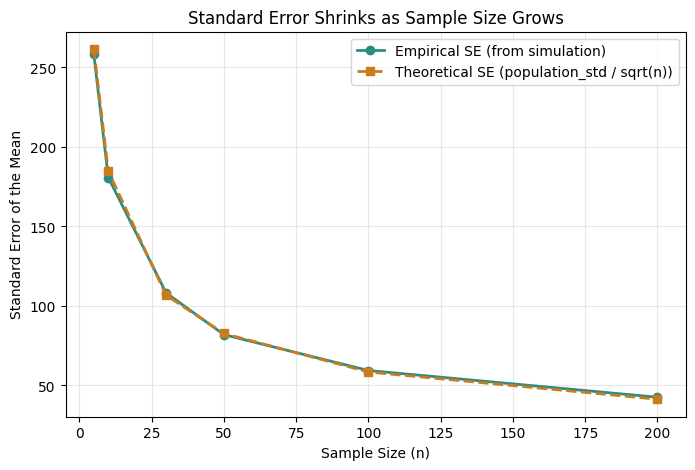

In [ ]:
# Create a figure 8 inches wide and 5 inches tall
plt.figure(figsize=(8, 5))

# Plot the empirical SE as a line with circular markers
plt.plot(sample_sizes, empirical_se_list, marker='o', color='#2A8C82', linewidth=2, label='Empirical SE (from simulation)')

# Plot the theoretical SE as a dashed line with square markers
plt.plot(sample_sizes, theoretical_se_list, marker='s', color='#C97C1C', linewidth=2, linestyle='--', label='Theoretical SE (population_std / sqrt(n))')

# Label the axes and add a title
plt.xlabel('Sample Size (n)')
plt.ylabel('Standard Error of the Mean')
plt.title('Standard Error Shrinks as Sample Size Grows')

# Show the legend
plt.legend()

# Add a light grid to make the chart easier to read
plt.grid(alpha=0.3)

# Display the chart
plt.show()


### Written Interpretation — Part 3 (Standard Error)
> **Purpose of this cell:** Explain what this chart means for collecting data in practice.

**Instructions:** Write 3-4 sentences addressing:
- **Pattern:** Describe the shape of the curve. Does SE decrease at a CONSTANT rate, or does it level off?
- **Empirical vs. Theoretical:** How closely do the simulated (empirical) values match the formula-based (theoretical) values? What does this tell you about the formula `SE = population_std / sqrt(n)`?
- **Practical decision:** If you were designing a NEW pilot study for the city council and Department of Labor, and doubling your sample size doubles your DATA COLLECTION COST, would you recommend going from n=30 to n=60? From n=100 to n=200? Use this chart to justify your answer.

---

`# TODO (your interpretation):`


## Part 4 — The Effect of Sample Size on Confidence Intervals
> **Purpose of this cell:** For each sample size in our list, draw ONE random sample, calculate its 95% confidence interval, and record the WIDTH of that interval (upper bound minus lower bound). Then plot CI width vs. sample size.
> **Methodology:** We reuse the `confidence_interval_95()` function idea from our Week 8 notebook: `CI width = 2 x (standard_error x t_critical_value)`. As `n` increases, BOTH the standard error AND the t-critical-value shrink slightly, so the CI gets narrower.

### New Concepts in This Cell
- **`stats.t.ppf(0.975, df)`** — same critical-value function from Week 8, but here we'll watch how it changes as our "degrees of freedom" (`df = n - 1`) increases.
- **List comprehension-style loop** — for each `n`, we draw ONE sample (not thousands), compute its CI width, and store the result. This mirrors what YOU would do in real life: collect ONE sample of a given size and compute ONE confidence interval from it.


In [ ]:
# Reuse the same list of sample sizes from Part 3
ci_sample_sizes = sample_sizes

# Empty list to store the CI width for each sample size
ci_widths = []

# Loop through each sample size
for n in ci_sample_sizes:
    # Draw ONE random sample of size n from the population
    sample = np.random.choice(population, size=n, replace=True)

    # Calculate this sample's mean and standard error
    sample_mean = np.mean(sample)
    sample_se = stats.sem(sample)

    # Find the critical t-value for a 95% confidence interval, with n-1 degrees of freedom
    t_crit = stats.t.ppf(0.975, n - 1)

    # The margin of error = standard error x critical t-value
    margin = sample_se * t_crit

    # The CI width = 2 x margin (the interval extends "margin" both above and below the mean)
    ci_width = 2 * margin
    ci_widths.append(ci_width)

# Build a small table showing sample size vs. CI width
ci_table = pd.DataFrame({
    'Sample Size (n)': ci_sample_sizes,
    '95% CI Width': np.round(ci_widths, 2)
})

print(ci_table)


   Sample Size (n)  95% CI Width
0                5       1307.09
1               10        810.27
2               30        393.94
3               50        306.13
4              100        250.44
5              200        163.31


## Part 4 (continued) — Visualizing Many Confidence Intervals at Once
> **Purpose of this cell:** Draw 100 different random samples, ALL of size **n = 30**, and plot ALL 100 of their 95% confidence intervals as horizontal lines. This lets us see what "95% confidence" actually MEANS.
> **Methodology:** For each of the 100 samples, we calculate its CI and check whether it CONTAINS the true population mean (the dashed vertical line). By definition, about 95% of these intervals SHOULD contain the true mean — let's verify that with our own simulation!

### New Concepts in This Cell
- **`plt.hlines(y, xmin, xmax)`** — draws a horizontal line at height `y`, from `xmin` to `xmax`. We use one horizontal line per sample, to represent that sample's confidence interval.
- **Counting "successes"** — we use a simple counter variable (`contains_true_mean = 0`) that we increase by 1 every time an interval contains the true population mean. At the end, we turn this count into a percentage.


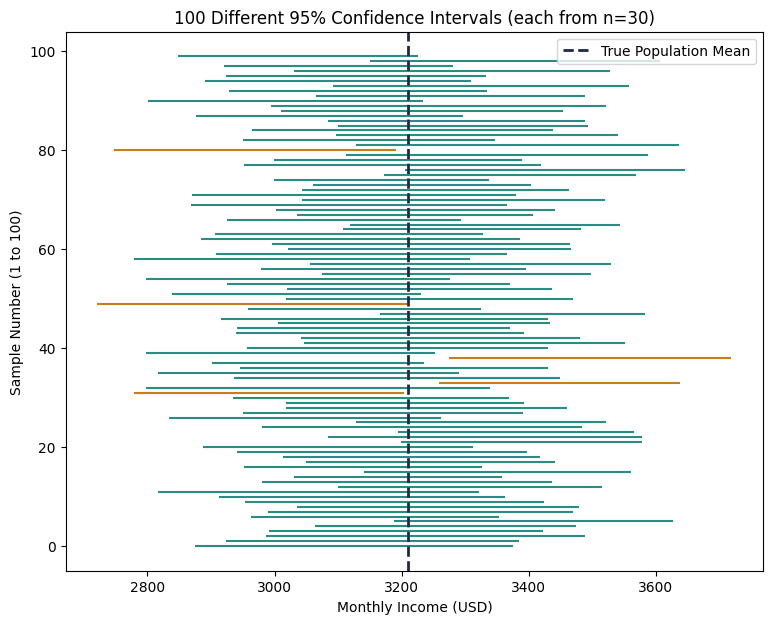

95 out of 100 intervals (95.0%) contained the true population mean.
(For a 95% confidence interval, we EXPECT this to be close to 95%.)


In [ ]:
# How many separate samples (and therefore separate confidence intervals) to draw
n_intervals = 100

# The fixed sample size to use for every one of these samples
n_fixed = 30

# Counter for how many of our intervals end up containing the TRUE population mean
contains_true_mean = 0

# Create a figure 9 inches wide and 7 inches tall
plt.figure(figsize=(9, 7))

# Loop through n_intervals separate samples
for i in range(n_intervals):
    # Draw a random sample of size n_fixed
    sample = np.random.choice(population, size=n_fixed, replace=True)

    # Calculate this sample's mean, standard error, and 95% CI bounds
    sample_mean = np.mean(sample)
    sample_se = stats.sem(sample)
    t_crit = stats.t.ppf(0.975, n_fixed - 1)
    margin = sample_se * t_crit
    lower = sample_mean - margin
    upper = sample_mean + margin

    # Check whether this interval contains the TRUE population mean
    # Color the line teal if YES (captures the true mean), amber if NO (misses it)
    if lower <= population_mean <= upper:
        color = '#2A8C82'
        contains_true_mean += 1
    else:
        color = '#C97C1C'

    # Draw this confidence interval as a horizontal line at height "i"
    plt.hlines(y=i, xmin=lower, xmax=upper, color=color, linewidth=1.5)

# Draw a vertical dashed line at the TRUE population mean
plt.axvline(population_mean, color='#1B2A4A', linestyle='--', linewidth=2, label='True Population Mean')

# Label the axes and add a title
plt.xlabel('Monthly Income (USD)')
plt.ylabel('Sample Number (1 to {})'.format(n_intervals))
plt.title(f'{n_intervals} Different 95% Confidence Intervals (each from n={n_fixed})')
plt.legend()

# Display the chart
plt.show()

# Print the percentage of intervals that captured the true mean
pct = (contains_true_mean / n_intervals) * 100
print(f"{contains_true_mean} out of {n_intervals} intervals ({pct:.1f}%) contained the true population mean.")
print("(For a 95% confidence interval, we EXPECT this to be close to 95%.)")


## Part 4 (continued) — Plotting CI Width vs. Sample Size
> **Purpose of this cell:** Turn the CI-width table from earlier into a chart showing how confidence interval width shrinks as sample size grows — visually similar to the SE chart in Part 3, because CI width is directly built from SE.


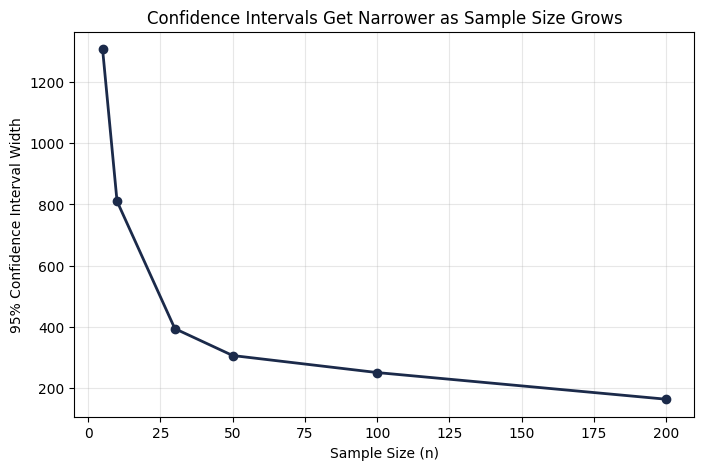

In [ ]:
# Create a figure 8 inches wide and 5 inches tall
plt.figure(figsize=(8, 5))

# Plot CI width vs sample size
plt.plot(ci_sample_sizes, ci_widths, marker='o', color='#1B2A4A', linewidth=2)

# Label the axes and add a title
plt.xlabel('Sample Size (n)')
plt.ylabel('95% Confidence Interval Width')
plt.title('Confidence Intervals Get Narrower as Sample Size Grows')

# Add a light grid
plt.grid(alpha=0.3)

# Display the chart
plt.show()


### Written Interpretation — Part 4 (Confidence Intervals)
> **Purpose of this cell:** Explain what these two charts mean for the city council and Department of Labor.

**Instructions:** Write 3-4 sentences addressing:
- **CI width vs. n:** How does CI width change as sample size increases? Is the relationship similar to what you saw with standard error in Part 3?
- **Coverage:** In the "many confidence intervals" chart, approximately what percentage of intervals contained the true population mean? Was this close to 95%? What does "95% confidence" actually mean, based on what you just saw?
- **Practical decision:** If a narrow confidence interval is important for estimating the average income impact of the program for a city budget proposal, what sample size would you recommend, based on this chart?

---

`# TODO (your interpretation):`


## Part 5 — The Effect of Sample Size on P-values and Hypothesis Testing Conclusions
> **Purpose of this cell:** Investigate how sample size affects our ability to detect the REAL difference between the Control and Treatment groups. We'll repeatedly draw SMALLER sub-samples from each group, run a t-test, and see how often we'd conclude "significant" vs. "not significant" — even though the FULL dataset (n=150 per group) shows a clear, significant difference.
> **Methodology:** For each sample size `n` in our list, we repeat 500 times:
> 1. Randomly draw `n` participants from the Control group's `Monthly_Income` values.
> 2. Randomly draw `n` participants from the Treatment group's `Monthly_Income` values.
> 3. Run a two-sample t-test and record the p-value.
>
> We then calculate, for each sample size, what PERCENTAGE of our 500 t-tests came back "significant" (p < 0.05). This percentage is closely related to a concept called **statistical power**.

### New Concepts in This Cell
- **Subsetting by group, THEN resampling** — first we split the data by `Group` (like in Week 8), and THEN draw random sub-samples from each group separately.
- **Tracking a "hit rate"** — for each sample size, we count how many of our 500 simulated t-tests produced p < 0.05, then convert that count into a percentage.

### Why This Matters
This directly affects real decisions! A pilot program tested on only 10 customers per group might show "no significant difference" even if the TRUE effect is real and large — simply because the sample was too small to detect it reliably.


In [ ]:
# Split the full dataset into Control and Treatment values for our outcome variable
control_values = df[df['Group'] == 'Control']['Monthly_Income'].values
treatment_values = df[df['Group'] == 'Treatment']['Monthly_Income'].values

# The list of (smaller) sample sizes we want to test, per group
p_sample_sizes = [5, 10, 20, 30, 50, 75, 100, 150]

# How many times to repeat the t-test simulation for EACH sample size
n_simulations_p = 500

# Empty lists to store results
pct_significant_list = []   # % of simulations that were significant, for each n
median_pvalue_list = []     # the median p-value across simulations, for each n

# Loop through each sample size
for n in p_sample_sizes:
    pvalues_for_this_n = []   # store every p-value from this round of simulations

    # Repeat the t-test n_simulations_p times
    for i in range(n_simulations_p):
        # Draw a random sub-sample of size n from EACH group, with replacement
        control_sub = np.random.choice(control_values, size=n, replace=True)
        treatment_sub = np.random.choice(treatment_values, size=n, replace=True)

        # Run the t-test on these two smaller sub-samples
        t_stat, p_val = stats.ttest_ind(control_sub, treatment_sub)
        pvalues_for_this_n.append(p_val)

    # Convert to a numpy array so we can do math on it easily
    pvalues_for_this_n = np.array(pvalues_for_this_n)

    # What % of these p-values were below 0.05 (i.e., "significant")?
    pct_significant = np.mean(pvalues_for_this_n < 0.05) * 100
    pct_significant_list.append(pct_significant)

    # What was the MIDDLE (median) p-value across all simulations for this n?
    median_pvalue_list.append(np.median(pvalues_for_this_n))

# Build a summary table
power_table = pd.DataFrame({
    'Sample Size per Group (n)': p_sample_sizes,
    '% of Tests Significant (p < 0.05)': np.round(pct_significant_list, 1),
    'Median P-value': np.round(median_pvalue_list, 4)
})

print(power_table)


   Sample Size per Group (n)  % of Tests Significant (p < 0.05)  \
0                          5                               57.8   
1                         10                               88.6   
2                         20                               99.8   
3                         30                              100.0   
4                         50                              100.0   
5                         75                              100.0   
6                        100                              100.0   
7                        150                              100.0   

   Median P-value  
0          0.0353  
1          0.0026  
2          0.0000  
3          0.0000  
4          0.0000  
5          0.0000  
6          0.0000  
7          0.0000  


## Part 5 (continued) — Plotting Statistical Power vs. Sample Size
> **Purpose of this cell:** Visualize how the percentage of "significant" results increases as sample size grows, with a reference line at 80% (a common minimum target for statistical power) and at the 5% false-positive rate.

### What to Look For
At very small sample sizes, the percentage of significant results may be LOW — meaning even though there IS a real difference between Control and Treatment (we know this from our full Week 8 analysis, with n=150 per group), a small study has a good chance of MISSING it. As `n` increases, this percentage should climb toward 100%.


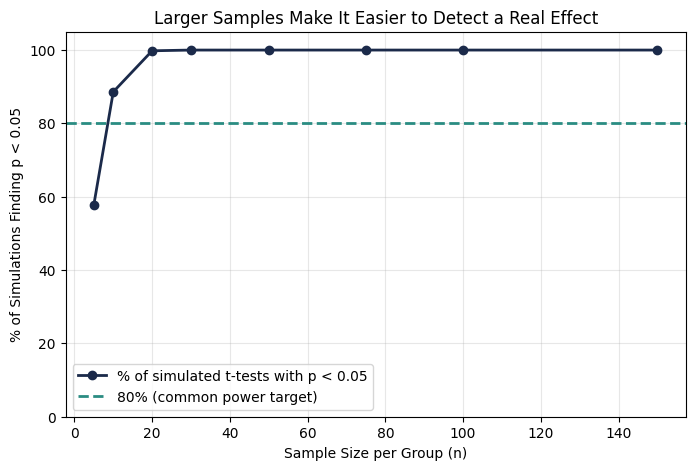

In [ ]:
# Create a figure 8 inches wide and 5 inches tall
plt.figure(figsize=(8, 5))

# Plot % significant vs. sample size
plt.plot(p_sample_sizes, pct_significant_list, marker='o', color='#1B2A4A', linewidth=2, label='% of simulated t-tests with p < 0.05')

# Draw a horizontal reference line at 80% (a common "statistical power" target)
plt.axhline(y=80, color='#2A8C82', linestyle='--', linewidth=2, label='80% (common power target)')

# Label the axes and add a title
plt.xlabel('Sample Size per Group (n)')
plt.ylabel('% of Simulations Finding p < 0.05')
plt.title('Larger Samples Make It Easier to Detect a Real Effect')

# Set the y-axis to run from 0 to 105 so the 80% line and 100% are both visible
plt.ylim(0, 105)

# Add a light grid and legend
plt.grid(alpha=0.3)
plt.legend()

# Display the chart
plt.show()


## Part 5 (continued) — A Closer Look: One Small Sample vs. One Large Sample
> **Purpose of this cell:** Draw ONE small sample (n = 5) and ONE large sample (n = 100) per group, run a t-test on each, and directly compare the t-statistic, p-value, and CONCLUSION (significant or not).
> **Methodology:** This is a single, concrete "before and after" example — rather than 500 repetitions, we just draw ONE pair of samples at each size, so you can see EXACTLY what the output of `stats.ttest_ind()` looks like at each size, side by side.


In [ ]:
# ----- SMALL SAMPLE (n = 5 per group) -----
small_control = np.random.choice(control_values, size=5, replace=True)
small_treatment = np.random.choice(treatment_values, size=5, replace=True)
small_t, small_p = stats.ttest_ind(small_control, small_treatment)

# ----- LARGE SAMPLE (n = 100 per group) -----
large_control = np.random.choice(control_values, size=100, replace=True)
large_treatment = np.random.choice(treatment_values, size=100, replace=True)
large_t, large_p = stats.ttest_ind(large_control, large_treatment)

# Print both results side by side for comparison
print("=" * 55)
print(f"SMALL SAMPLE (n = 5 per group)")
print(f"  Control mean:   {np.mean(small_control):.2f}")
print(f"  Treatment mean: {np.mean(small_treatment):.2f}")
print(f"  T-statistic:    {small_t:.4f}")
print(f"  P-value:        {small_p:.4f}")
print(f"  Conclusion:     {'SIGNIFICANT' if small_p < 0.05 else 'NOT SIGNIFICANT'}")
print("=" * 55)
print(f"LARGE SAMPLE (n = 100 per group)")
print(f"  Control mean:   {np.mean(large_control):.2f}")
print(f"  Treatment mean: {np.mean(large_treatment):.2f}")
print(f"  T-statistic:    {large_t:.4f}")
print(f"  P-value:        {large_p:.4f}")
print(f"  Conclusion:     {'SIGNIFICANT' if large_p < 0.05 else 'NOT SIGNIFICANT'}")
print("=" * 55)


SMALL SAMPLE (n = 5 per group)
  Control mean:   2906.25
  Treatment mean: 3715.17
  T-statistic:    -3.3491
  P-value:        0.0101
  Conclusion:     SIGNIFICANT
LARGE SAMPLE (n = 100 per group)
  Control mean:   2964.65
  Treatment mean: 3613.92
  T-statistic:    -10.1046
  P-value:        0.0000
  Conclusion:     SIGNIFICANT


### Written Interpretation — Part 5 (P-values and Hypothesis Testing)
> **Purpose of this cell:** Tie this entire notebook together with a final reflection on sample size and decision-making.

**Instructions:** Write 4-5 sentences addressing:
- **Power curve:** Describe the shape of the "% significant" curve from the first Part 5 chart. At what sample size does it start to consistently exceed 80%?
- **Small vs. large sample comparison:** Compare the t-statistic and p-value between your small sample and large sample in the cell above. Did the CONCLUSION (significant vs. not significant) differ? Did the underlying MEANS (Control vs. Treatment) differ much between the small and large samples?
- **Risk of small samples:** If the city council and Department of Labor ran a pilot with only 5 participants per group and got a "not significant" result, would that PROVE the program doesn't work? What else could explain a "not significant" result with a small sample?
- **Tying it all together:** In your own words, explain how the CLT (Part 2), standard error (Part 3), confidence intervals (Part 4), and p-values (Part 5) are all CONNECTED. (Hint: they all depend on the same underlying idea — the spread of the sampling distribution, which shrinks as `n` grows.)

---

`# TODO (your interpretation):`


## Part 6 — Probability: Modeling Outcomes with the Normal Distribution
> **Purpose of this cell:** Use the normal distribution (justified by the CLT!) to calculate the PROBABILITY that a randomly chosen participant's Monthly Income (USD) falls above or below a meaningful threshold — and compare that theoretical probability to what we ACTUALLY observe in our data.
> **Methodology:** We treat each group's `Monthly_Income` values as approximately normal (mean = group mean, std = group standard deviation). Then we use `stats.norm.cdf()` — the **cumulative distribution function** — to calculate the probability that a value falls below a given threshold. The probability of falling ABOVE the threshold is simply `1 - cdf`.

### Our Question
What is the probability that a randomly selected participant's Monthly_Income is BELOW the $3,200 Self-Sufficiency Wage? We'll calculate this for BOTH the Control and Treatment groups, and compare.

### New Concepts in This Cell
- **`stats.norm.cdf(x, loc, scale)`** — returns the probability that a normally-distributed variable with mean `loc` and standard deviation `scale` is LESS THAN OR EQUAL TO `x`. This is a single number between 0 and 1.
- **Empirical probability** — instead of using a formula, we can also just COUNT: out of all our actual participants, what FRACTION had a value past the threshold? `(data > threshold).mean()` does exactly this — it turns `True`/`False` into `1`/`0` and averages them, giving a proportion.
- **Comparing theoretical vs. empirical** — if the normal distribution is a good MODEL for our data, these two numbers (theoretical and empirical probability) should be close.


In [ ]:
# The threshold value we're interested in
threshold = 3200

# Split the outcome variable into Control and Treatment groups (if not already defined above)
control_outcome_full = df[df['Group'] == 'Control']['Monthly_Income'].values
treatment_outcome_full = df[df['Group'] == 'Treatment']['Monthly_Income'].values

# Loop through both groups and calculate probabilities for each
for group_name, data in [('Control', control_outcome_full), ('Treatment', treatment_outcome_full)]:

    # Calculate this group's mean and standard deviation
    group_mean = np.mean(data)
    group_std = np.std(data)

    # THEORETICAL probability using the normal distribution (cdf = "cumulative distribution function")
    # stats.norm.cdf(threshold, mean, std) gives P(X <= threshold)
    theoretical_prob_below = stats.norm.cdf(threshold, loc=group_mean, scale=group_std)
    theoretical_prob_above = 1 - theoretical_prob_below

    # EMPIRICAL probability: directly count the fraction of actual data points above/below the threshold
    empirical_prob_above = np.mean(data > threshold)
    empirical_prob_below = np.mean(data <= threshold)

    # Print a summary for this group
    print(f"--- {group_name} group (mean={group_mean:.2f}, std={group_std:.2f}) ---")
    print(f"  Theoretical P(X > {threshold}) = {theoretical_prob_above:.3f}   |   Empirical P(X > {threshold}) = {empirical_prob_above:.3f}")
    print(f"  Theoretical P(X <= {threshold}) = {theoretical_prob_below:.3f}   |   Empirical P(X <= {threshold}) = {empirical_prob_below:.3f}")
    print()


--- Control group (mean=2851.66, std=490.22) ---
  Theoretical P(X > 3200) = 0.239   |   Empirical P(X > 3200) = 0.253
  Theoretical P(X <= 3200) = 0.761   |   Empirical P(X <= 3200) = 0.747

--- Treatment group (mean=3569.09, std=431.34) ---
  Theoretical P(X > 3200) = 0.804   |   Empirical P(X > 3200) = 0.820
  Theoretical P(X <= 3200) = 0.196   |   Empirical P(X <= 3200) = 0.180



## Part 6 (continued) — Visualizing the Probability as Shaded Area
> **Purpose of this cell:** Draw each group's normal curve and SHADE the region corresponding to the probability we just calculated, so "probability" becomes something you can literally SEE as an area under a curve.
> **Methodology:** We draw the normal curve for each group using `stats.norm.pdf()`, then use `plt.fill_between()` to shade the area beyond our threshold.

### New Concepts in This Cell
- **`plt.fill_between(x, y, where=condition, color=..., alpha=...)`** — shades the area under a curve, but ONLY where `condition` is `True`. We'll use this to shade only the portion of the curve beyond our threshold.


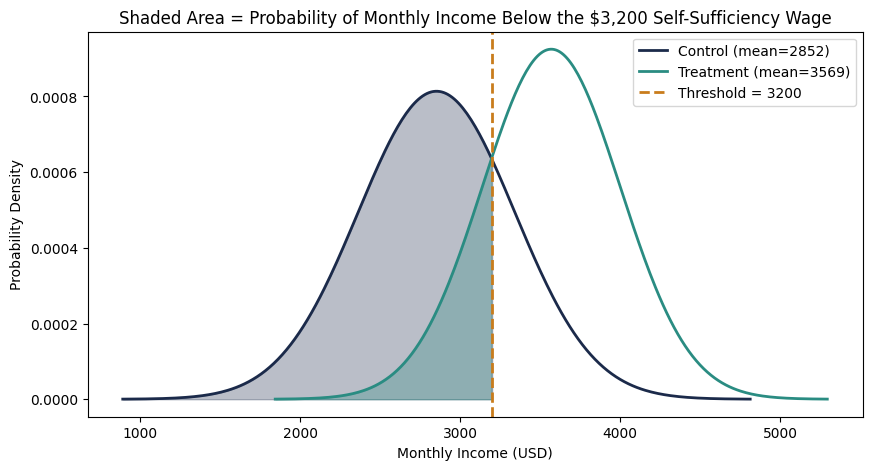

In [ ]:
# Create a figure 10 inches wide and 5 inches tall
plt.figure(figsize=(10, 5))

# Loop through both groups, plotting each on the same chart
for group_name, data, color in [('Control', control_outcome_full, '#1B2A4A'), ('Treatment', treatment_outcome_full, '#2A8C82')]:

    group_mean = np.mean(data)
    group_std = np.std(data)

    # Create a smooth range of x-values spanning 4 standard deviations around the mean
    x_vals = np.linspace(group_mean - 4 * group_std, group_mean + 4 * group_std, 300)

    # Calculate the height of the normal curve at each x-value
    y_vals = stats.norm.pdf(x_vals, group_mean, group_std)

    # Draw the curve
    plt.plot(x_vals, y_vals, color=color, linewidth=2, label=f'{group_name} (mean={group_mean:.0f})')

    # Shade the area where x is past our threshold (the region whose probability we calculated above)
    plt.fill_between(x_vals, y_vals, where=(x_vals <= threshold), color=color, alpha=0.3)

# Draw a vertical line marking the threshold
plt.axvline(threshold, color='#C97C1C', linestyle='--', linewidth=2, label=f'Threshold = {threshold}')

# Label the axes and add a title
plt.xlabel('Monthly Income (USD)')
plt.ylabel('Probability Density')
plt.title("Shaded Area = Probability of Monthly Income Below the $3,200 Self-Sufficiency Wage")
plt.legend()

# Display the chart
plt.show()


### Written Interpretation — Part 6 (Probability)
> **Purpose of this cell:** Translate these probabilities into a statement the city council and Department of Labor could use.

**Instructions:** Write 3-4 sentences addressing:
- **Theoretical vs. empirical:** How close were the theoretical (normal-distribution-based) and empirical (actual count-based) probabilities for each group? What does this tell you about whether the normal distribution is a reasonable MODEL for this data?
- **Comparing groups:** Which group has a higher probability of Monthly Income Below the $3,200 Self-Sufficiency Wage? Does this match what you'd expect based on the group means from Week 8?
- **Plain-language statement:** Write ONE sentence, with NO statistical jargon, that the city council and Department of Labor could use to describe this probability. (Example structure: "Out of every 100 participants in the [Control/Treatment] group, about ___ would be expected to ___.")

---

`# TODO (your interpretation):`


## Part 7 — Expected Value: Putting a Number on a Decision Under Uncertainty
> **Purpose of this cell:** Calculate the **Expected Value (EV)** of Expanding the Fast-Track Vocational Training Program, given a set of possible scenarios, each with its own probability and payoff.
> **Methodology:** Expected Value is calculated as:
>
> $$EV = \sum (\text{probability of scenario} \times \text{payoff of scenario})$$
>
> In plain language: multiply each possible outcome by how likely it is to happen, then add up all those products. This gives you a single number representing the "average" outcome IF this decision were repeated many, many times.

### Our Scenario Table
| Scenario | Probability | Net Annual Value per Participant |
|---|---|---|
| Effect Persists (Best Case) | 0.60 | +$3,609.16 |
| Partial Fade (Effect Shrinks by Half) | 0.30 | -$695.42 |
| No Real Effect (Worst Case) | 0.10 | -$5,000.00 |

*(Net Annual Value = (monthly income increase x 12) - $5,000 program cost per participant)*

> **Important:** These probabilities are ESTIMATES, informed by (but not directly calculated from) our Week 8 statistical results — specifically, the p-value and confidence interval tell us how confident we can be that a real effect exists, which is reflected in how we've assigned these scenario probabilities. In your presentation, you should discuss WHERE these probability estimates come from and whether you'd change them.

### New Concepts in This Cell
- **`np.array([...])`** — we'll store our probabilities and payoffs as two separate arrays (lists of numbers), then multiply them together element-by-element.
- **`np.sum(probabilities * payoffs)`** — numpy lets us multiply two arrays together directly (each element with its matching element), then `np.sum()` adds up the results. This is exactly the EV formula above.
- **`assert`** — a simple check that stops the program with an error if something is wrong. We use it here to confirm our probabilities add up to 1.0 (100%) — a requirement for any valid probability distribution.


In [ ]:
# The probability of each scenario (must add up to 1.0)
probabilities = np.array([0.60, 0.30, 0.10])

# The payoff (in $ Net Annual Value per Participant) associated with each scenario
payoffs = np.array([3609.16, -695.42, -5000.00])

# Sanity check: probabilities must add up to 1.0 (100%)
assert np.isclose(probabilities.sum(), 1.0), "Probabilities must sum to 1.0!"

# Calculate the Expected Value: multiply each probability by its payoff, then sum
expected_value = np.sum(probabilities * payoffs)

# Print each scenario individually
scenario_names = ['Effect Persists', 'Partial Fade', 'No Real Effect']
for name, p, payoff in zip(scenario_names, probabilities, payoffs):
    print(f"  {name}: probability = {p:.2f}, payoff = {payoff:,.2f}, contribution to EV = {p * payoff:,.2f}")

print()
print(f"EXPECTED VALUE of Expanding the Fast-Track Vocational Training Program: {expected_value:,.2f} ($ Net Annual Value per Participant)")
print(f"Compare to the alternative ('Continue Standard Job-Search Assistance (Status Quo)'), which has a payoff of 0.00")


  Effect Persists: probability = 0.60, payoff = 3,609.16, contribution to EV = 2,165.50
  Partial Fade: probability = 0.30, payoff = -695.42, contribution to EV = -208.63
  No Real Effect: probability = 0.10, payoff = -5,000.00, contribution to EV = -500.00

EXPECTED VALUE of Expanding the Fast-Track Vocational Training Program: 1,456.87 ($ Net Annual Value per Participant)
Compare to the alternative ('Continue Standard Job-Search Assistance (Status Quo)'), which has a payoff of 0.00


## Part 7 (continued) — Visualizing the Scenarios and the Expected Value
> **Purpose of this cell:** Draw a bar chart showing each scenario's payoff (sized/colored by its probability) alongside a horizontal line marking the Expected Value — the probability-weighted "average" across all scenarios.


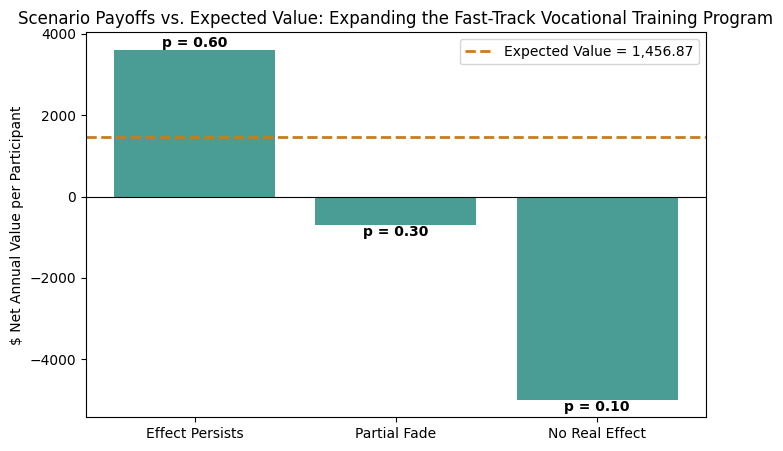

In [ ]:
# Create a figure 8 inches wide and 5 inches tall
plt.figure(figsize=(8, 5))

# Draw one bar per scenario, with height = payoff
bars = plt.bar(scenario_names, payoffs, color='#2A8C82', alpha=0.85)

# Add the probability of each scenario as text above its bar
for bar, p in zip(bars, probabilities):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'p = {p:.2f}',
             ha='center', va='bottom' if height >= 0 else 'top', fontweight='bold')

# Draw a horizontal dashed line at the Expected Value
plt.axhline(expected_value, color='#C97C1C', linestyle='--', linewidth=2,
            label=f'Expected Value = {expected_value:,.2f}')

# Draw a horizontal line at 0 for reference
plt.axhline(0, color='black', linewidth=0.8)

# Label the axes and add a title
plt.ylabel('$ Net Annual Value per Participant')
plt.title('Scenario Payoffs vs. Expected Value: Expanding the Fast-Track Vocational Training Program')
plt.legend()

# Display the chart
plt.show()


### Written Interpretation — Part 7 (Expected Value)
> **Purpose of this cell:** Decide what this Expected Value means for the city council and Department of Labor.

**Instructions:** Write 4-5 sentences addressing:
- **Comparing options:** How does the Expected Value of Expanding the Fast-Track Vocational Training Program compare to the alternative (Continue Standard Job-Search Assistance (Status Quo))? Based ONLY on Expected Value, which option looks better?
- **Where do probabilities come from?** Look back at the probabilities you were given in the scenario table. How might your Week 8 p-value and confidence interval (which tell you how CONFIDENT you can be that a real effect exists) inform how you'd assign these probabilities?
- **The problem with "average" outcomes:** Expected Value tells you the average result if a decision were repeated MANY times. But the city council and Department of Labor will only make this decision ONCE (or a limited number of times). What's a risk of relying ONLY on Expected Value for a one-time decision? (Think about the WORST-case scenario in your table — how would the city council and Department of Labor feel if THAT happened, even if it's unlikely?)
- **Sensitivity:** If you changed the probability of the worst-case scenario from what's given to something HIGHER, how do you think that would change the Expected Value? (You don't need to recalculate — just reason about the direction of the change.)

---

`# TODO (your interpretation):`


## Part 8 — Monte Carlo Simulation: Simulating Thousands of Possible Futures
> **Purpose of this cell:** Instead of picking just 2-3 scenarios (like Part 7), we'll simulate **5,000 possible futures**, where the TRUE effect of expanding the Fast-Track program is allowed to vary randomly within a realistic range based on our Week 8 data. For each simulated future, we calculate Annual ROI (%). The result is an entire DISTRIBUTION of possible outcomes — not just one number.
> **Methodology:** For each of the 5,000 simulated futures, we BOOTSTRAP a new Control sample and a new Treatment sample (same sizes as our real data, drawn with replacement), calculate the difference in their mean Monthly_Income, project it over 12 months, and divide by the $5,000 program cost per participant to get an Annual ROI percentage. This gives us 5,000 plausible values for the program's Annual ROI.

### New Concepts in This Cell
- **A Monte Carlo simulation** is just a `for` loop that repeats a calculation many times, with RANDOM inputs drawn fresh each time — very similar to what we did in Parts 2-5, but now applied to a real DECISION rather than just a statistic.
- **`np.random.choice(..., replace=True)`** (bootstrap resampling) — used here exactly as in Parts 2-5, to simulate "what if we ran this program again with a new group of participants?"
- **Calculating a probability from simulation results** — once we have 5,000 simulated outcomes, we can ask: "what FRACTION of these outcomes were greater than 100% (i.e., the program returns more in annual income gains than it costs)?" That fraction IS a probability — directly comparable to the probabilities we had to GUESS in Part 7!


In [ ]:
# Number of simulated futures to generate
n_trials = 5000

# Empty array (all zeros) to store the simulated outcome for each future
mc_outcomes = np.zeros(n_trials)

# The assumed program cost, per participant
program_cost = 5000.00

# Repeat the simulation n_trials times
for i in range(n_trials):
    # Bootstrap: draw a brand-new random sample from each group, same size as our real data, with replacement
    control_sample = np.random.choice(control_outcome_full, size=len(control_outcome_full), replace=True)
    treatment_sample = np.random.choice(treatment_outcome_full, size=len(treatment_outcome_full), replace=True)

    # Calculate the difference in average Monthly_Income for THIS simulated future
    monthly_diff = np.mean(treatment_sample) - np.mean(control_sample)

    # Project this monthly difference over 12 months to get the annual income increase
    annual_diff = monthly_diff * 12

    # Express the annual income increase as a percentage of the program cost (i.e., Annual ROI)
    mc_outcomes[i] = (annual_diff / program_cost) * 100

# Calculate the probability that Annual ROI exceeds 100%
mc_probability = np.mean(mc_outcomes > 100)


## Part 8 (continued) — Visualizing the Distribution of Simulated Outcomes
> **Purpose of this cell:** Plot a histogram of all 5,000 simulated values of Annual ROI (%), marking the mean (which should be close to a "Monte Carlo Expected Value"), zero (or the relevant target), and shading the probability region we calculated.


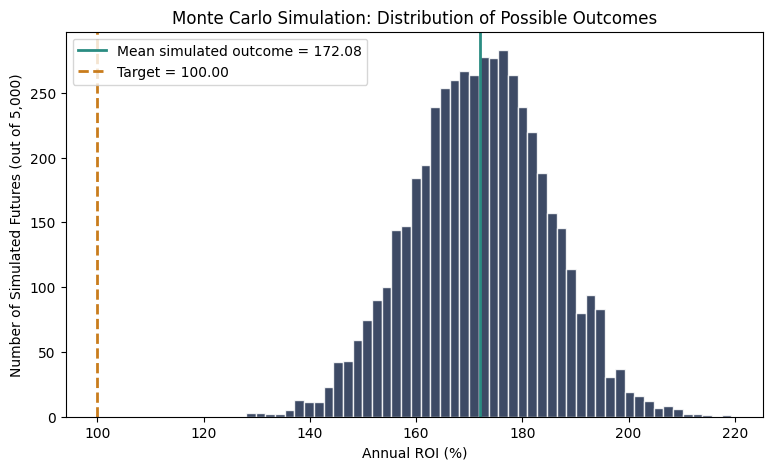

Mean simulated Annual ROI (%): 172.08
Standard deviation across simulations: 12.82
5th percentile (a 'pessimistic' outcome): 150.67
95th percentile (an 'optimistic' outcome): 193.13
Probability that Annual ROI (%) is greater than 100%: 100.0%


In [ ]:
# Create a figure 9 inches wide and 5 inches tall
plt.figure(figsize=(9, 5))

# Draw a histogram of all simulated outcomes
plt.hist(mc_outcomes, bins=50, color='#1B2A4A', edgecolor='white', alpha=0.85)

# Draw a vertical line at the MEAN simulated outcome (the "Monte Carlo Expected Value")
plt.axvline(np.mean(mc_outcomes), color='#2A8C82', linewidth=2, linestyle='-',
            label=f'Mean simulated outcome = {np.mean(mc_outcomes):,.2f}')

# Draw a vertical line at the target threshold
plt.axvline(100.0, color='#C97C1C', linewidth=2, linestyle='--',
            label=f'Target = 100.00')

# Label the axes and add a title
plt.xlabel('Annual ROI (%)')
plt.ylabel('Number of Simulated Futures (out of 5,000)')
plt.title('Monte Carlo Simulation: Distribution of Possible Outcomes')
plt.legend()

# Display the chart
plt.show()

# Print the key Monte Carlo results
print(f"Mean simulated Annual ROI (%): {np.mean(mc_outcomes):,.2f}")
print(f"Standard deviation across simulations: {np.std(mc_outcomes):,.2f}")
print(f"5th percentile (a 'pessimistic' outcome): {np.percentile(mc_outcomes, 5):,.2f}")
print(f"95th percentile (an 'optimistic' outcome): {np.percentile(mc_outcomes, 95):,.2f}")
print(f"Probability that Annual ROI (%) is greater than 100%: {mc_probability:.1%}")


### Written Interpretation — Part 8 (Monte Carlo Simulation)
> **Purpose of this cell:** This is the FINAL reflection for your presentation — bring everything together.

**Instructions:** Write 5-6 sentences addressing:
- **Shape of the distribution:** Describe the shape of the histogram of simulated outcomes. Is it roughly symmetric? Where is most of the "mass" of the distribution — above or below the target line?
- **Monte Carlo EV vs. Part 7 EV:** How does the MEAN of the simulated outcomes compare to the Expected Value you calculated by hand in Part 7? Which approach do you find more convincing, and why?
- **The probability you calculated:** State, in plain language with NO jargon, the probability that Annual ROI (%) meets the target. What would you tell the city council and Department of Labor using this single number?
- **Pessimistic vs. optimistic outcomes:** Using the 5th and 95th percentile values printed above, describe the RANGE of plausible outcomes. How wide is this range? Does it change your confidence in the decision?
- **Connecting it all:** This Monte Carlo simulation uses the SAME bootstrap resampling idea from Parts 2-5 (the CLT, standard error, and confidence intervals). In your own words, explain how the UNCERTAINTY we quantified in Parts 2-5 (using sample size and standard error) flows directly into the WIDTH of the distribution you see here.
- **Final recommendation:** Based on EVERYTHING in this notebook — the CLT, standard error, confidence intervals, p-values, probability, expected value, and this Monte Carlo simulation — what would YOU recommend to the city council and Department of Labor, and what is the SINGLE piece of evidence from this notebook you'd lead with in a presentation?

---

`# TODO (your interpretation):`
